In [1]:
import pandas as pd

data = {
    'Date': [
        '2024-01-05','2024-01-12','2024-02-08','2024-02-20',
        '2024-03-10','2024-03-25','2024-04-15','2024-04-28',
        '2024-05-06','2024-05-18'
    ],
    'Product': [
        'Laptop','Mouse','Keyboard','Laptop',
        'Monitor','Mouse','Keyboard','Monitor',
        'Laptop','Mouse'
    ],
    'Category': [
        'Electronics','Accessories','Accessories','Electronics',
        'Electronics','Accessories','Accessories','Electronics',
        'Electronics','Accessories'
    ],
    'Sales': [
        1200, 200, 350, 1500,
        800, 250, 400, 900,
        1800, 300
    ]
}

df = pd.DataFrame(data)

# Save it as a CSV file
df.to_csv('sales_data.csv', index=False)

print("Sample dataset created successfully!")
df.head()

Sample dataset created successfully!


,Date,Product,Category,Sales
0,2024-01-05,Laptop,Electronics,1200
1,2024-01-12,Mouse,Accessories,200
2,2024-02-08,Keyboard,Accessories,350
3,2024-02-20,Laptop,Electronics,1500
4,2024-03-10,Monitor,Electronics,800


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

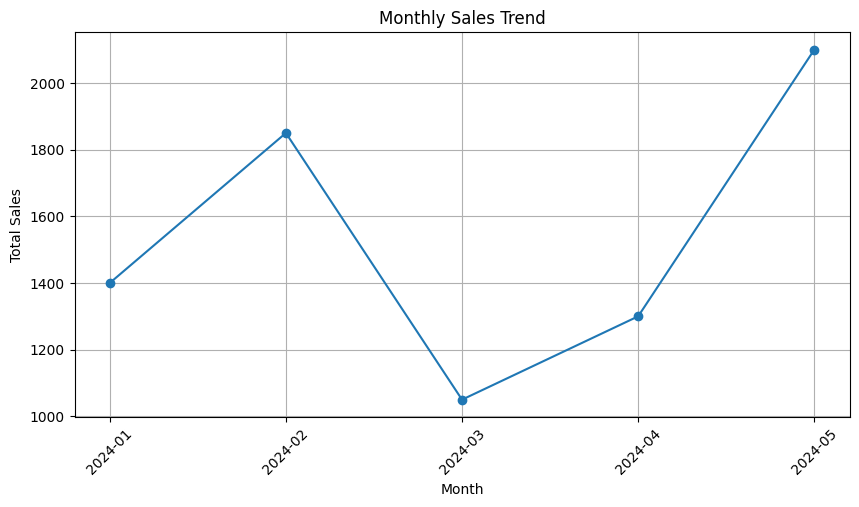

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = (
    df.groupby(df['Date'].dt.to_period('M'))['Sales']
      .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig("monthly_sales_trend.png")
plt.show()

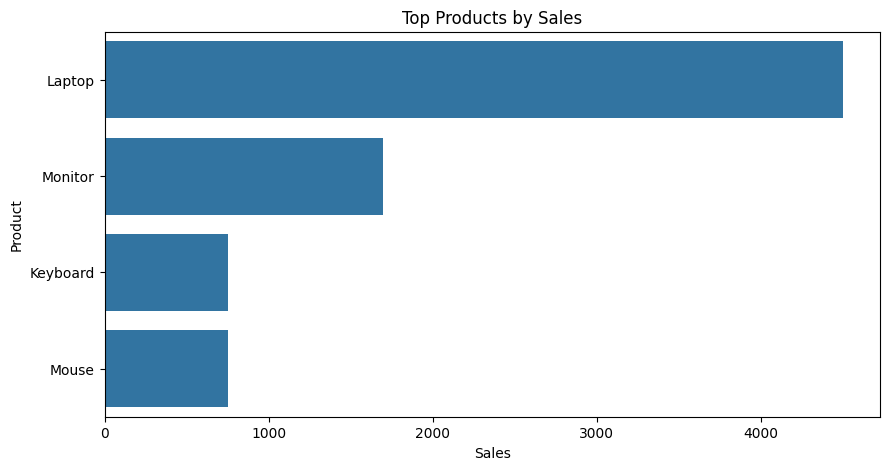

In [4]:
top_products = (
    df.groupby('Product')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

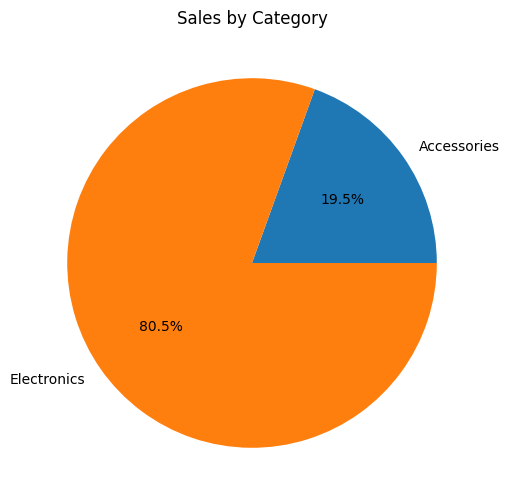

In [5]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%'
)

plt.title("Sales by Category")

plt.show()

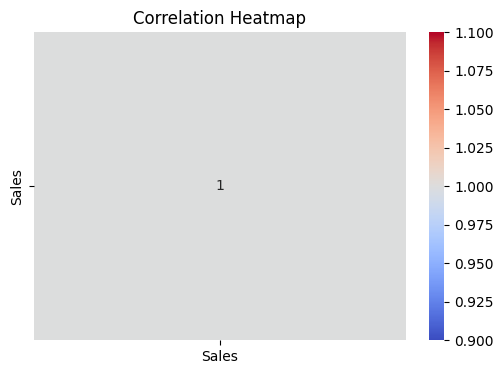

In [6]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()